In [1]:
import matplotlib.pyplot as plt

from core.momentum.camera_to_world_mapper import CameraToWorldMapper
from core.momentum.domain import TrackedPoint


def display_frame(frame, figsize=(12, 8)):
    """Display a frame from OpenCV in Jupyter

    Args:
        frame: numpy array from cv2.read()
        figsize: tuple of (width, height) for display
    """
    # Convert BGR (OpenCV) to RGB (matplotlib)
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=figsize)
    plt.imshow(rgb_frame)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def display_frame_with_points(frame, points, radius=5, color=(0, 255, 0), thickness=2):
    """Display frame with points drawn on it

    Args:
        frame: numpy array from cv2.read()
        points: list of (x, y) tuples
        radius: circle radius
        color: BGR color tuple (default: green)
        thickness: -1 for filled circle, positive for outline
    """
    # Make a copy to avoid modifying original
    frame_copy = frame.copy()

    # Draw circles at each point
    for i, (x, y) in enumerate(points):
        cv2.circle(frame_copy, (x, y), radius, color, thickness)
        # Optional: add point number
        cv2.putText(frame_copy, str(i+1), (x+10, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    # Convert BGR to RGB for matplotlib
    rgb_frame = cv2.cvtColor(frame_copy, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(rgb_frame)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return frame_copy, points

Loaded frame 0: shape=(1080, 1920, 3)


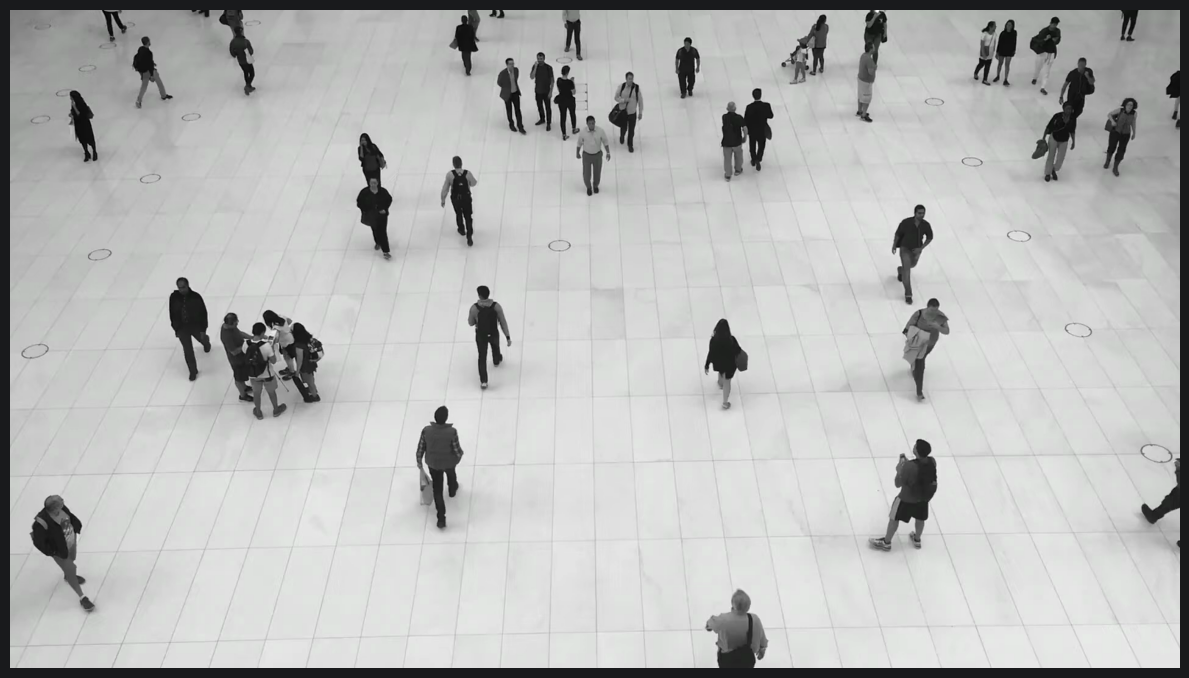

In [2]:
import cv2

from project_root import PROJECT_ROOT

# Load a single frame from MP4
video_path = PROJECT_ROOT / "data/datasets/yt/walking_people.mp4"
cap = cv2.VideoCapture(video_path)

# Get frame by index (0 for first frame)
frame_index = 0
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
ret, frame = cap.read()

if ret:
    print(f"Loaded frame {frame_index}: shape={frame.shape}")
    display_frame(frame)
    cv2.imwrite("frame.jpg", frame)

else:
    print("Failed to read frame")

cap.release()

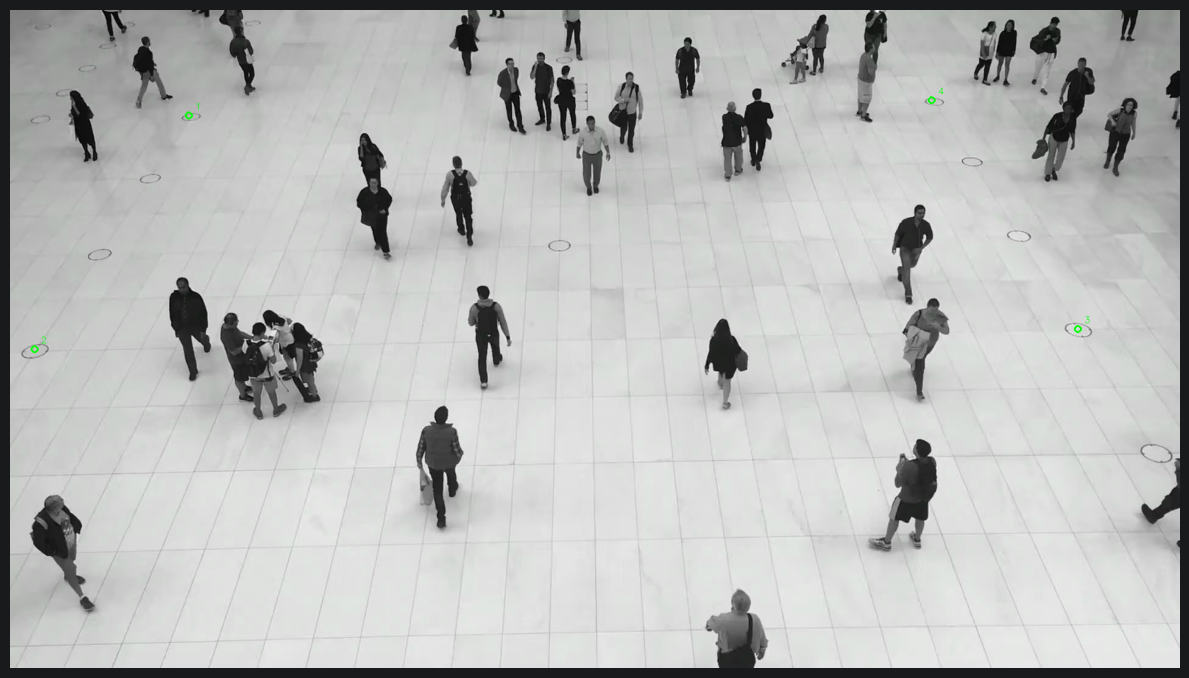

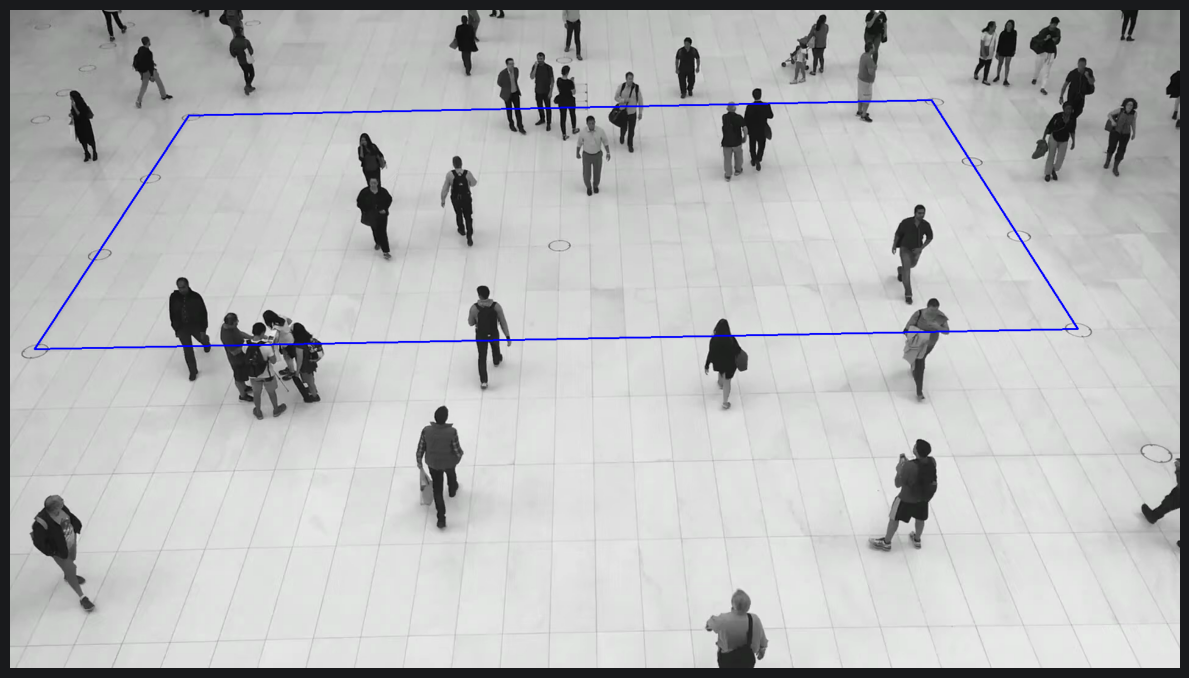

In [3]:
import numpy as np
keypoints = np.array(
[
    [293, 174],  # Example keypoint 1
    [40, 557],  # Example keypoint 2
    [1752, 524],  # Example keypoint 3]
    [1512, 149],
]
)

display_frame_with_points(frame, keypoints)
img = cv2.polylines(frame.copy(), [np.array(keypoints)], isClosed=True, color=(255, 0, 0), thickness=2)
display_frame(img)

In [4]:
real_world_pts = np.array([[0, 0], [0, 6], [15, 6], [15, 0]]).astype(np.float32)
M = cv2.getPerspectiveTransform(keypoints.astype(np.float32), real_world_pts)
print(M)

[[ 1.55288694e-02  1.02579737e-02 -6.33484615e+00]
 [ 5.66734925e-04  2.76339949e-02 -4.97436845e+00]
 [ 3.12462976e-05  1.32643238e-03  1.00000000e+00]]


In [5]:

keypoints_v2 = np.array(
    [
        [293, 174],  # Example keypoint 1
        [40, 557],  # Example keypoint 2
        [1752, 524],  # Example keypoint 3]
        [1512, 149],
        [0, 0],
        [1919, 1079]
    ],
    dtype=np.float32
)
for cords in keypoints_v2:
    hc = np.concatenate([cords, [1]])
    y = np.matmul(M, hc)
    print(y[:2] / y[2])

kk = keypoints_v2.copy().reshape(-1, 1, 2)
transformed_points = cv2.perspectiveTransform(kk, M)
print(transformed_points.reshape(-1, 2))

[0. 0.]
[0. 6.]
[15.  6.]
[15.  0.]
[-6.33484615 -4.97436845]
[13.86225707 10.40882381]
[[ 0.         0.       ]
 [ 0.         6.       ]
 [15.         6.       ]
 [15.         0.       ]
 [-6.334846  -4.9743686]
 [13.862257  10.408824 ]]


In [6]:
from core.momentum.momentum import TrackedPoint
temp = TrackedPoint(10, 20)
print(np.array(temp).reshape(-1, 1, 2))

[[[10 20]]]


In [7]:
from core.momentum.camera_to_world_mapper import CameraToWorldMapper
ctw = CameraToWorldMapper(M)
points = [TrackedPoint(293, 174), TrackedPoint(40, 557)]
print(ctw.map(points[0]))
print(ctw.map_batch(points))


TrackedPoint(x=np.float32(0.0), y=np.float32(0.0))
[TrackedPoint(x=np.float32(0.0), y=np.float32(0.0)), TrackedPoint(x=np.float32(0.0), y=np.float32(6.0))]


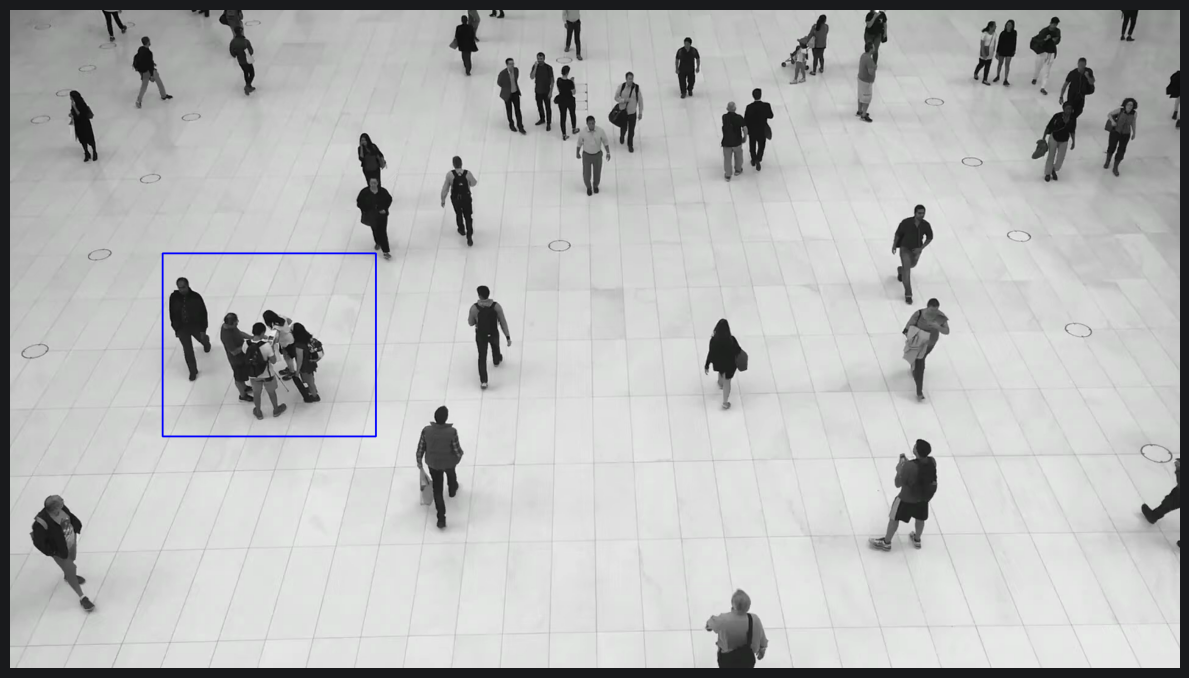

In [12]:
polygon = [(250, 400), (250, 700), (600, 700), (600, 400)]


img = cv2.polylines(frame.copy(), [np.array(polygon)], isClosed=True, color=(255, 0, 0), thickness=2)
display_frame(img)
